## 進化動学

**ゲーム** : このゲームでは店側と客側の2つのプレイヤーが存在します。プレイヤーは選択肢 (0, 1) があり選択肢によってそれぞれ利得が決まる。

# 利得表
# 利得は (店の利得, 客の利得) で表される。
# |         | 店: O | 店: I |
# |---------|-------|-------|
# | 客: O    |  1, 1  |  0, -1  |
# | 客: I    |  -1, 0  |  3, 3  |

しかし、実社会では沢山の店があり、沢山の客がいます。そこで、進化動学を用いてこのゲームを解析します。
店、客をエージェントとし、その集団をプレイヤーとしてゲームを分析する。（混合戦略）

## 混合戦略
**戦略**
各プレイヤーの戦略は各エージェントが取りえる手の割合で表現される。
例えば、店の戦略がx=0.2であれば、店のエージェントの20%が選択肢Oを選び、80%が選択肢Iを選ぶことを意味する。
**利得**
利得は各エージェントの利得の平均で計算される。

## 反復ゲーム
このゲームを反復的に行い、各プレイヤーの戦略が時間とともにどのように変化するかを観察します。
現実は各エージェントは利得の最大化の戦略は特定できません。そのため、現実では大衆の行動に基づいて戦略を更新します。流行に乗ってものを選ぶことがあります。（大衆戦略の模倣）。
進化動学では、各エージェントは自分の利得と大衆の利得を比較し、自分の利得が低ければ大衆の戦略を模倣します。これにより、各プレイヤーの戦略は時間とともに変化します。（反復ゲーム）

### エージェントの作成

In [1]:
class PlayerRole():
    """
    strgSet: 戦略の集合 list[num] (例: [0, 1])
    payMat: 利得行列 list[list] n次元の配列, nは戦略の数 (例: n=2の場合[[1, 0], [-1, 3]]) 
    nmStrg: 戦略の数 int (例: 2)
    revProt: ゲームの更新のための関数
    """
    def __init__(self, strgSet, payMat, revProt):
        self.strgSet = strgSet
        self.payMat = payMat
        self.nmStrg = len(self.strgSet)
        self.revProt = revProt
    
    def expPayFn(self, strgDist_opp):
        # 相手（opp = opponent）
        """
        strgDist_opp: 相手の戦略分布 list[num] (例: [0.7, 0.3] -> 相手が戦略0をとる確率が70%, 戦略1をとる確率が30%)
        """
        # 期待利得のベクトルの初期化
        expPayVec = [0 for i in range(self.nmStrg)] 
        # 期待利得の計算
        for strgId_Id in range(self.nmStrg):
            for strgId_opp in range(len(strgDist_opp)):
                expPayVec[strgId_Id] += self.payMat[strgId_Id][strgId_opp] * strgDist_opp[strgId_opp]
        return expPayVec

In [2]:
## 例: 2戦略のゲーム
# プレイヤー1
# 戦略の集合
strgSet_1 = [0, 1]
# 利得行列
payMat_1 = [[1, 0], [-1, 3]]
player1 = PlayerRole(strgSet_1, payMat_1, None)
# プレイヤー2
# 戦略の集合
strgSet_2 = [0, 1]
# 利得行列
payMat_2 = [[-1, 1], [0, -3]]
player2 = PlayerRole(strgSet_2, payMat_2, None)

# 利得表
"""
|                  | Player 2: Strg 0 | Player 2: Strg 1 |
|------------------|------------------|------------------|
| Player 1: Strg 0 | (1, -1)          | (0, 0)           |
| Player 1: Strg 1 | (-1, 1)          | (3, -3)          |

"""

# プレイヤー1の戦略分布
strgDist_1 = [0.7, 0.3]
# プレイヤー2の戦略分布
strgDist_2 = [0.4, 0.6]
# プレイヤー1の期待利得の計算
expPayVec_1 = player1.expPayFn(strgDist_2)
print("Player 1's expected payoff vector:", expPayVec_1)
# プレイヤー2の期待利得の計算
expPayVec_2 = player2.expPayFn(strgDist_1)
print("Player 2's expected payoff vector:", expPayVec_2)

# 計算式
"""
Player 1's Strg payoff vector:
    strg 0: 1 * 0.4 + 0 * 0.6 = 0.4
    strg 1: -1 * 0.4 + 3 * 0.6 = 1.4
Player 2's Strg payoff vector:
    strg 0: -1 * 0.7 + 1 * 0.3 = -0.4
    strg 1: 0 * 0.7 + (-3) * 0.3 = 0.9
"""

Player 1's expected payoff vector: [0.4, 1.4]
Player 2's expected payoff vector: [-0.39999999999999997, -0.8999999999999999]


"\nPlayer 1's Strg payoff vector:\n    strg 0: 1 * 0.4 + 0 * 0.6 = 0.4\n    strg 1: -1 * 0.4 + 3 * 0.6 = 1.4\nPlayer 2's Strg payoff vector:\n    strg 0: -1 * 0.7 + 1 * 0.3 = -0.4\n    strg 1: 0 * 0.7 + (-3) * 0.3 = 0.9\n"

##  進化動学: 利得を比較して各戦略から他の戦略に移る確率を求める
スイッチングレート：プレイヤーが戦略を更新しやすさを表すパラメータ。スイッチングレートが高いほど、プレイヤーは戦略を更新する傾向がある。

In [3]:
import numpy as np

# IoS: Imitation of Success（成功の模倣）
# 期待利得が高い戦略へ乗り換える
def IoS(payMat, expPayVec, strgDist_own, expPayAdd=0):
    """
    payMat: 利得行列
    expPayVec: 現在の期待利得ベクトル
    strgDist_own: 自分集団の現在の戦略分布
    expPayAdd: 期待利得に足す定数
    """

    # 戦略ID集合
    strgIdSet = range(len(expPayVec))

    # 利得行列の最大値
    maxPay = np.max(payMat)

    # 遷移行列を初期化
    switchMtrx = [[0 for _ in strgIdSet] for _ in strgIdSet]

    # 現在の戦略（FROM）
    for strgIdFrom in strgIdSet:
        tempVec = [0 for _ in strgIdSet]

        # 次の戦略（TO）で、FROM と異なる戦略への遷移確率を計算
        for strgIdTo in [i for i in strgIdSet if i != strgIdFrom]:
            tempVec[strgIdTo] = (
                strgDist_own[strgIdTo]
                * (expPayVec[strgIdTo] + expPayAdd)
                / (maxPay + expPayAdd)
            )

        # 行ごとに反映
        switchMtrx[strgIdFrom] = tempVec

        # 残りを「そのまま残る確率」にする
        switchMtrx[strgIdFrom][strgIdFrom] = 1 - sum(tempVec)

    return switchMtrx

# stdBRD: Best Response Dynamics（最適反応動学）
def stdBRD(payMat, expPayVec, strgDist_own):
    """
    payMat: 利得行列
    expPayVec: 現在の期待利得ベクトル
    strgDist_own: 自分集団の現在の戦略分布
    """

    # 戦略ID集合
    strgIdSet = range(len(expPayVec))

    # 期待利得の最大値
    maxExpPay = max(expPayVec)

    # 期待利得が最大の戦略IDを集めたリスト
    maxStrgId = [strgId for strgId in strgIdSet if expPayVec[strgId] == maxExpPay]

    # 遷移行列を初期化
    switchMtrx = [[0 for _ in strgIdSet] for _ in strgIdSet]

    # 現在の戦略（FROM）
    for strgIdFrom in strgIdSet:
        # 次の戦略（TO）
        for strgIdTo in maxStrgId:
            # 最適反応集合に均等に移る
            switchMtrx[strgIdFrom][strgIdTo] = 1 / len(maxStrgId)

    return switchMtrx

def tBRD(payMat, expPayVec, strgDist_own):
    """
    payMat: 利得行列
    expPayVec: 現在の期待利得ベクトル
    strgDist_own: 自分集団の現在の戦略分布
    """

    # 戦略ID集合
    strgIdSet = range(len(expPayVec))

    # 期待利得の最大値
    maxExpPay = max(expPayVec)

    # 期待利得が最大の戦略IDを集めたリスト
    maxStrgId = [strgId for strgId in strgIdSet if expPayVec[strgId] == maxExpPay]

    # 利得行列全体の利得幅
    payoff_range = np.max(payMat) - np.min(payMat)

    # 遷移行列を初期化
    switchMtrx = [[0 for _ in strgIdSet] for _ in strgIdSet]

    # 現在の戦略（FROM）
    for strgIdFrom in strgIdSet:
        tempVec = [0 for _ in strgIdSet]

        # 次の戦略（TO）
        for strgIdTo in [i for i in maxStrgId if i != strgIdFrom]:
            # 現在の戦略の期待利得が低いほど、最適反応へ移りやすい
            tempVec[strgIdTo] = (
                (maxExpPay - expPayVec[strgIdFrom])
                / (payoff_range * len(maxStrgId))
            )

        # 行ごとに反映
        switchMtrx[strgIdFrom] = tempVec

        # 残りを「そのまま残る確率」にする
        switchMtrx[strgIdFrom][strgIdFrom] = 1 - sum(tempVec)

    return switchMtrx

## 各プレイヤーの戦略更新のシミュレーション

In [4]:
class AggPlayer(PlayerRole):
    # 戦略分布の更新のための関数
    def aggTrans(self, strgDist_own, strgDist_opp):
        """
        strgDist_own: 自分の集団における戦略分布 list[num]
        (例: [0.7, 0.3] → 集団の70%が戦略i、30%が戦略j)

        strgDist_opp: 相手集団における戦略分布 list[num]
        (例: [0.4, 0.6] → 相手集団の40%が戦略i、60%が戦略j)
        """
        # 相手分布に対する現在の期待利得ベクトルを計算
        expPayVec = self.expPayFn(strgDist_opp)

        # 更新ルール関数 dyn に、
        # 「利得行列」「期待利得ベクトル」「自分の現在分布」を渡して遷移行列を作る
        switchMtrx = self.revProt(self.payMat, expPayVec, strgDist_own)

        # 各戦略の純増減（流入 - 流出）を記録するベクトル
        transVec = [0 for _ in range(self.nmStrg)]

        # from -> to のフローを集計
        for strgIdFrom in range(self.nmStrg):
            for strgIdTo in range(self.nmStrg):
                # 戦略Fromの人が戦略Toへ移る人数
                flow = strgDist_own[strgIdFrom] * switchMtrx[strgIdFrom][strgIdTo]

                # Toへの流入を加算
                transVec[strgIdTo] += flow

                # Fromからの流出を減算
                transVec[strgIdFrom] -= flow

        return transVec
    
    # シミュレーション
    def aggTrans_binary(self,strg1Share_own,strg1Share_opp):
        """
        strg1Share_own: 自分の集団における戦略1の割合 float (例: 0.7 → 集団の70%が戦略1)
        strg1Share_opp: 相手集団における戦略1の割合 float (例: 0.4 → 相手集団の40%が戦略1)
        """
        # 2戦略なので [戦略0の割合, 戦略1の割合] に直す
        strgDist_own = [1 - strg1Share_own, strg1Share_own]
        strgDist_opp = [1 - strg1Share_opp, strg1Share_opp]

        # 戦略分布の変化ベクトルを計算
        transVec = self.aggTrans(strgDist_own, strgDist_opp)

        # 戦略1の変化量だけ返す
        return transVec[1]

## 遷移ベクトルのプロット

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# プロットのための方眼の作成
gridUnit=0.05 #グリッドの間隔
pRange = np.arange(0,1+gridUnit,gridUnit)#縦軸上(p)の方眼の値
qRange = np.arange(0,1+gridUnit,gridUnit)#横軸上(q)の方眼の値
pGrid, qGrid = np.meshgrid(pRange, qRange)# 方眼を作成

def phasePlot(dPFn, dQFn):
    #Calculate a transition vector and scale it down
    dP=[[0 for qId in range(len(pRange))]for pId in range(len(pRange))]
    dQ=[[0 for qId in range(len(pRange))]for pId in range(len(pRange))]
    dNorm=[[0 for qId in range(len(pRange))]for pId in range(len(pRange))]
    statP=[];statQ=[]
    stopThresh=0.0000001
    for pId in range(len(pRange)):
        for qId in range(len(pRange)):
            # p, q が戦略A をとる割合
            p=pGrid[pId][qId]
            q=qGrid[pId][qId]
            # シミュレーション（スイッチングレート）
            dp=dPFn(p,q)
            dq=dQFn(q,p)
            # ベクトルの大きさを計算
            dNorm[pId][qId] = np.sqrt(pow(dp,2)+pow(dq,2))
            # ベクトルの静止点を判定
            if dNorm[pId][qId]<stopThresh:
                dP[pId][qId] = 0
                dQ[pId][qId] = 0
                dNorm[pId][qId] = 0
                statP.append(p);statQ.append(q)
            # ベクトルの大きさが0でない場合は、ベクトルを正規化して描画するための値を計算
            else:
                dP[pId][qId] = dp/dNorm[pId][qId]
                dQ[pId][qId] = dq/dNorm[pId][qId]

    print("Number of stationary points:",len(statP))
    plt.quiver(pGrid, qGrid, dP, dQ,dNorm, cmap='gnuplot2',scale=1/(0.9*gridUnit), width=0.2*gridUnit)
    plt.scatter(statP,statQ,c='k')

Number of stationary points: 5


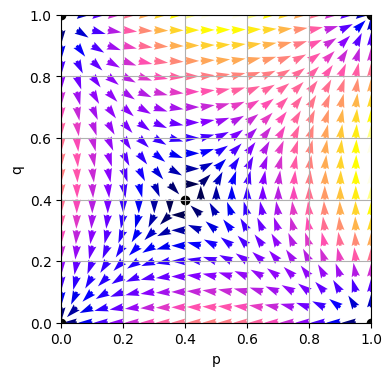

'\nグラフの解説：\n横軸p: プレイヤー1の集団における戦略1の割合\n縦軸q: プレイヤー2の集団における戦略1の割合\n矢印: pとqの変化の方向 (右: pが増える, 左: pが減る, 上: qが増える, 下: qが減る)\n矢印（色）: 変化の大きさ (赤: 大きい, 青: 小さい)\n点: どちらに行くか分からない（境界）\n'

In [6]:
# プレイヤー1とプレイヤー2の集団を作成
# 戦略のID
strgSet = [0, 1]
# 戦略の利得行列
payMat = [[1, 0], [-1, 3]]

# 戦略の変更モデル
dyn = IoS
# プレイヤー1の集団
aggCust=AggPlayer(strgSet, payMat, dyn)
# プレイヤー2の集団
aggComp=AggPlayer(strgSet, payMat, dyn)

plt.figure(figsize=(4, 4)) # 図の設定
plt.xlabel('p') # x軸ラベル
plt.ylabel('q') # y軸ラベル
plt.xlim(0,1); plt.ylim(0,1)
phasePlot(aggCust.aggTrans_binary, aggComp.aggTrans_binary)
plt.grid() # グリッド線
plt.show()

"""
グラフの解説：
横軸p: プレイヤー1の集団における戦略1の割合
縦軸q: プレイヤー2の集団における戦略1の割合
矢印: pとqの変化の方向 (右: pが増える, 左: pが減る, 上: qが増える, 下: qが減る)
矢印（色）: 変化の大きさ (赤: 大きい, 青: 小さい)
点: どちらに行くか分からない（境界）
"""

## 個々人レベルのシミュレーション

In [7]:
import random
import numpy as np

class Agent(PlayerRole):
    rev_prob = 0.01
    def __init__(self,strgSet,payMat,revProt,initStrgId):
        super().__init__(strgSet,payMat,revProt)
        """
        strgId: プレイヤーの現在の戦略 int (例: 0 -> 戦略0をとる, 1 -> 戦略1をとる)
        """
        self.strgId= initStrgId

    # 低確率 (rev_prob) で、確率分布に従って戦略を更新する
    def updateStrg(self,switchProbVec):
        """
        switchProbVec: 各戦略に移る確率のベクトル list[num] (例: [0.7, 0.3] -> 戦略0に移る確率が70%, 戦略1に移る確率が30%)
        """
        if random.uniform(0,1) < self.rev_prob: # 0から1の間の乱数がrev_probより小さい場合に戦略を更新
            self.strgId = np.random.choice(a=range(len(self.strgSet)),p=switchProbVec)